# 프로젝트: mini BERT 만들기
- SentencePiece vocab size: **8,000** (특수 토큰을 포함한 실제 모델 크기는 8,007)
- mini BERT: 약 **1M parameters**
- Pre-training: MLM + NSP, **10 epochs**

> `bert_data/kowiki.txt`를 준비한 뒤 위에서 아래 순서로 실행하세요. 전체 코퍼스 전처리와 10 epoch 학습에는 시간이 오래 걸릴 수 있습니다.

## 0. 환경 및 경로 설정

**설명:** 이 단계는 실행 환경과 파일 저장 위치를 통일합니다. 이후 단계는 이 경로를 기준으로 데이터를 읽고 모델을 저장합니다.

In [41]:
# Install missing packages into the active Jupyter kernel environment.
import importlib.util
import subprocess
import sys

required_packages = {
    "torch": "torch",
    "sentencepiece": "sentencepiece",
    "tqdm": "tqdm",
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
}
missing_packages = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing_packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing_packages])

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import os
import re
import math
import numpy as np
import pandas as pd
import random
import collections
import json
import shutil
import zipfile
import copy
from datetime import datetime

import matplotlib.pyplot as plt
import sentencepiece as spm
from tqdm.notebook import tqdm

random_seed = 1234
random.seed(random_seed)
np.random.seed(random_seed)

print(torch.__version__)
from pathlib import Path

data_dir = Path("bert_data")
model_dir = Path("bert_models")
data_dir.mkdir(exist_ok=True)
model_dir.mkdir(exist_ok=True)

corpus_file = data_dir / "kowiki.txt"



2.11.0+cu128


In [42]:
# Download and extract kowiki only when it is not already available.
from urllib.request import urlretrieve

corpus_url = "https://d3s0tskafalll9.cloudfront.net/media/documents/kowiki.txt.zip"
archive_file = data_dir / "kowiki.txt.zip"

if not corpus_file.exists():
    if not archive_file.exists():
        print("Downloading kowiki corpus...")
        urlretrieve(corpus_url, archive_file)
    print("Extracting corpus archive...")
    with zipfile.ZipFile(archive_file) as archive:
        archive.extractall(data_dir)

assert corpus_file.exists(), f"Corpus was not found after extraction: {corpus_file}"
print(f"Corpus ready: {corpus_file}")


Corpus ready: bert_data\kowiki.txt


## 1. Tokenizer 준비

한글 위키 코퍼스로 SentencePiece BPE tokenizer를 학습합니다. BERT 특수 토큰 7개를 별도로 포함합니다.

**설명:** 코퍼스 문장을 subword 토큰으로 분해할 토크나이저를 학습합니다. BERT 입력에 필요한 특수 토큰도 함께 등록합니다.

In [43]:
# [핵심] BERT 특수 토큰을 포함한 SentencePiece vocabulary를 학습합니다.
vocab_size = 8000
prefix = model_dir / "ko_8000"

spm.SentencePieceTrainer.train(
    f"--input={corpus_file} --model_prefix={prefix} --vocab_size={vocab_size + 7} "
    "--model_type=bpe --max_sentence_length=999999 "
    "--pad_id=0 --pad_piece=[PAD] --unk_id=1 --unk_piece=[UNK] "
    "--bos_id=2 --bos_piece=[BOS] --eos_id=3 --eos_piece=[EOS] "
    "--user_defined_symbols=[SEP],[CLS],[MASK]"
)


In [44]:
vocab = spm.SentencePieceProcessor()
vocab.load(str(model_dir / "ko_8000.model"))

vocab_list = [
    vocab.id_to_piece(token_id)
    for token_id in range(7, len(vocab))
    if not vocab.is_unknown(token_id)
]
print(f"Vocabulary size: {len(vocab)}")


Vocabulary size: 8007


## 2. 데이터 전처리 (1): whole-word MLM mask 생성

전체 토큰의 15%를 단어 단위로 선택해 80%는 `[MASK]`, 10%는 원본, 10%는 임의 토큰으로 바꿉니다.

**설명:** MLM은 가려진 토큰의 원래 값을 맞히는 과제입니다. 서브워드 조각이 아닌 단어 단위로 마스킹해 너무 쉬운 예측을 줄입니다.

In [45]:
# [핵심] 단어 단위로 선택한 토큰을 MLM 입력과 정답으로 분리합니다.

def create_pretrain_mask(tokens, mask_cnt, vocab_list):
    """
    마스크 생성
    :param tokens: tokens
    :param mask_cnt: mask 개수 (전체 tokens의 15%)
    :param vocab_list: vocab list (random token 용)
    :return tokens: mask된 tokens
    :return mask_idx: mask된 token의 index
    :return mask_label: mask된 token의 원래 값
    """
    
    cand_idx = []
    for (i, token) in enumerate(tokens):
        if token == "[CLS]" or token == "[SEP]":
            continue
        if 0 < len(cand_idx) and not token.startswith(u"\u2581"):
            cand_idx[-1].append(i)
        else:
            cand_idx.append([i])

    
    random.shuffle(cand_idx)
    mask_lms = []
    for index_set in cand_idx:
        if len(mask_lms) >= mask_cnt:
            break
        if len(mask_lms) + len(index_set) > mask_cnt:
            continue
        dice = random.random()
        for index in index_set:
            masked_token = None
            if dice < 0.8:
                masked_token = "[MASK]"
            elif dice < 0.9:
                masked_token = tokens[index]
            else:
                masked_token = random.choice(vocab_list)
            mask_lms.append({"index": index, "label": tokens[index]})
            tokens[index] = masked_token

    
    mask_lms = sorted(mask_lms, key=lambda x: x["index"])
    mask_idx = [p["index"] for p in mask_lms]
    mask_label = [p["label"] for p in mask_lms]

    return tokens, mask_idx, mask_label

## 3. 데이터 전처리 (2): NSP pair 생성

문장 쌍을 구성하고, 절반의 확률로 순서를 바꿔 NSP 레이블을 만듭니다.

**설명:** NSP는 두 문장이 원래 이어졌는지 판별합니다. segment id는 두 문장이 입력의 어느 부분인지 모델에 알려줍니다.

In [46]:
def trim_tokens(tokens_a, tokens_b, max_seq):
    """
    tokens_a, tokens_b의 길이를 줄임 최대 길이: max_seq
    :param tokens_a: tokens A
    :param tokens_b: tokens B
    :param max_seq: 두 tokens 길이의 최대 값
    """
    while True:
        total_length = len(tokens_a) + len(tokens_b)
        if total_length <= max_seq:
            break

        if len(tokens_a) > len(tokens_b):
            del tokens_a[0]
        else:
            tokens_b.pop()

In [47]:
# [핵심] 문장 쌍, segment id, NSP 레이블을 한 학습 예제로 묶습니다.

def create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list):
    """
    doc별 pretrain 데이터 생성
    """
    
    max_seq = n_seq - 3

    instances = []
    current_chunk = []
    current_length = 0
    for i in range(len(doc)):

        current_chunk.append(doc[i])
        current_length += len(doc[i])
        if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):
            a_end = 1
            if 1 < len(current_chunk):
                a_end = random.randrange(1, len(current_chunk))
            tokens_a = []
            for j in range(a_end):
                tokens_a.extend(current_chunk[j])
            tokens_b = []
            for j in range(a_end, len(current_chunk)):
                tokens_b.extend(current_chunk[j])

            if random.random() < 0.5:
                is_next = 0
                tokens_t = tokens_a
                tokens_a = tokens_b
                tokens_b = tokens_t
            else:
                is_next = 1
            trim_tokens(tokens_a, tokens_b, max_seq)
            assert 0 < len(tokens_a)
            assert 0 < len(tokens_b)
            tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
            segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)
            tokens, mask_idx, mask_label = create_pretrain_mask(tokens, int((len(tokens) - 3) * mask_prob), vocab_list)

            instance = {
                "tokens": tokens,
                "segment": segment,
                "is_next": is_next,
                "mask_idx": mask_idx,
                "mask_label": mask_label
            }
            instances.append(instance)

            current_chunk = []
            current_length = 0
    return instances

## 4. 데이터 전처리 (3): 데이터셋 저장 및 로드

전처리 데이터를 JSONL로 저장한 뒤 `np.memmap`으로 메모리 효율적으로 로드합니다.

**설명:** 전처리 결과를 JSONL로 저장한 뒤 학습에 바로 쓸 정수 배열로 변환합니다. memmap은 큰 배열을 디스크 기반으로 다루게 합니다.

In [48]:
# [핵심] 문서별 예제를 JSONL 파일에 순차 저장해 메모리 사용량을 제한합니다.

def make_pretrain_data(vocab, in_file, out_file, n_seq, mask_prob=0.15):
    """ pretrain 데이터 생성 """
    def save_pretrain_instances(out_f, doc):
        instances = create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list)
        for instance in instances:
            out_f.write(json.dumps(instance, ensure_ascii=False))
            out_f.write("\n")

    
    vocab_list = []
    for id in range(7, len(vocab)):
        if not vocab.is_unknown(id):        
            vocab_list.append(vocab.id_to_piece(id))

    
    line_cnt = 0
    with open(in_file, "r", encoding="utf-8") as in_f:
        for line in in_f:
            line_cnt += 1

    with open(in_file, "r", encoding="utf-8") as in_f:
        with open(out_file, "w", encoding="utf-8") as out_f:
            doc = []
            for line in tqdm(in_f, total=line_cnt):
                line = line.strip()
                if line == "":  
                    if 0 < len(doc):
                        save_pretrain_instances(out_f, doc)
                        doc = []
                else:  
                    pieces = vocab.encode_as_pieces(line)
                    if 0 < len(pieces):
                        doc.append(pieces)
            if 0 < len(doc):  
                save_pretrain_instances(out_f, doc)
                doc = []

In [49]:
# [핵심] JSONL 예제를 고정 길이의 memmap 배열로 변환합니다.
def load_pre_train_data(vocab, filename, n_seq, count=None):
    """
    학습에 필요한 데이터를 로드
    :param vocab: vocab
    :param filename: 전처리된 json 파일
    :param n_seq: 시퀀스 길이 (number of sequence)
    :param count: 데이터 수 제한 (None이면 전체)
    :return enc_tokens: encoder inputs
    :return segments: segment inputs
    :return labels_nsp: nsp labels
    :return labels_mlm: mlm labels
    """
    total = 0
    with open(filename, "r", encoding="utf-8") as f:
        for line in f:
            total += 1
            
            if count is not None and count <= total:
                break

    
    enc_tokens = np.memmap(filename=str(data_dir / 'enc_tokens.memmap'), mode='w+', dtype=np.int32, shape=(total, n_seq))
    segments = np.memmap(filename=str(data_dir / 'segments.memmap'), mode='w+', dtype=np.int32, shape=(total, n_seq))
    labels_nsp = np.memmap(filename=str(data_dir / 'labels_nsp.memmap'), mode='w+', dtype=np.int32, shape=(total,))
    labels_mlm = np.memmap(filename=str(data_dir / 'labels_mlm.memmap'), mode='w+', dtype=np.int32, shape=(total, n_seq))

    with open(filename, "r", encoding="utf-8") as f:
        for i, line in enumerate(tqdm(f, total=total)):
            if total <= i:
                print("data load early stop", total, i)
                break
            data = json.loads(line)
            
            enc_token = [vocab.piece_to_id(p) for p in data["tokens"]]
            enc_token += [0] * (n_seq - len(enc_token))
            
            segment = data["segment"]
            segment += [0] * (n_seq - len(segment))
            
            label_nsp = data["is_next"]
            
            mask_idx = np.array(data["mask_idx"], dtype=np.int32)
            mask_label = np.array([vocab.piece_to_id(p) for p in data["mask_label"]], dtype=np.int32)
            label_mlm = np.full(n_seq, dtype=np.int32, fill_value=0)
            label_mlm[mask_idx] = mask_label

            assert len(enc_token) == len(segment) == len(label_mlm) == n_seq

            enc_tokens[i] = enc_token
            segments[i] = segment
            labels_nsp[i] = label_nsp
            labels_mlm[i] = label_mlm

    return (enc_tokens, segments), (labels_nsp, labels_mlm)

In [50]:
N_SEQ = 128
pretrain_json_path = data_dir / "bert_pre_train.json"

# 전체 코퍼스에 대한 JSONL 데이터셋 생성 (최초 1회 실행)
make_pretrain_data(vocab, corpus_file, pretrain_json_path, N_SEQ)

# 환경에 맞게 학습 샘플 수를 조절하세요. None이면 전체를 사용합니다.
MAX_TRAIN_SAMPLES = 128_000
pre_train_inputs, pre_train_labels = load_pre_train_data(
    vocab, pretrain_json_path, N_SEQ, count=MAX_TRAIN_SAMPLES
)


  0%|          | 0/3957761 [00:00<?, ?it/s]

  0%|          | 0/128000 [00:00<?, ?it/s]

data load early stop 128000 128000


## 5. BERT 모델 구현

Embedding, Transformer encoder, MLM/NSP head를 포함한 약 1M parameter mini BERT를 구성합니다.

**설명:** 세 종류의 embedding을 더한 뒤 Transformer encoder를 통과시켜 문맥 표현을 만듭니다. 이 표현으로 MLM과 NSP를 함께 예측합니다.

In [51]:
def get_pad_mask(tokens, i_pad=0):
    """
    pad mask 계산하는 함수
    :param tokens: tokens (bs, n_seq)
    :param i_pad: id of pad
    :return mask: pad mask (pad: 1, other: 0)
    """
    mask = (tokens == i_pad).float()
    mask = mask.unsqueeze(1)
    return mask

def get_ahead_mask(tokens, i_pad=0):
    """
    ahead mask 계산하는 함수
    :param tokens: tokens (bs, n_seq)
    :param i_pad: id of pad
    :return mask: ahead and pad mask (ahead or pad: 1, other: 0)
    """
    n_seq = tokens.size(1)
    ahead_mask = 1 - torch.tril(torch.ones((n_seq, n_seq)))
    ahead_mask = ahead_mask.unsqueeze(0)
    pad_mask = get_pad_mask(tokens, i_pad)
    mask = torch.maximum(ahead_mask, pad_mask)
    return mask



In [52]:
def gelu(x):
    """
    gelu activation 함수
    :param x: 입력 값
    :return: gelu activation result
    """
    return 0.5 * x * (1 + torch.tanh(math.sqrt(2 / math.pi) * (x + 0.044715 * torch.pow(x, 3))))



In [53]:
def kernel_initializer(stddev=0.02):
    """
    parameter initializer 생성
    :param stddev: 생성할 랜덤 변수의 표준편차
    """
    return torch.nn.init.trunc_normal_

def bias_initializer():
    """
    bias initializer 생성
    """
    return torch.zeros_



In [54]:
class Config(dict):
    """
    json을 config 형태로 사용하기 위한 Class
    :param dict: config dictionary
    """
    __getattr__ = dict.__getitem__
    __setattr__ = dict.__setitem__

    @classmethod
    def load(cls, file):
        """
        file에서 Config를 생성 함
        :param file: filename
        """
        with open(file, 'r') as f:
            config = json.loads(f.read())
            return Config(config)


In [55]:
class SharedEmbedding(nn.Module):
    """
    Weighed Shared Embedding Class
    """
    def __init__(self, config, name="weight_shared_embedding"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.n_vocab = config.n_vocab
        self.d_model = config.d_model
        self.shared_weights = nn.Parameter(torch.empty(self.n_vocab, self.d_model))
        nn.init.trunc_normal_(self.shared_weights, std=0.02)  

    def forward(self, inputs, mode="embedding"):
        """
        layer 실행
        :param inputs: 입력
        :param mode: 실행 모드
        :return: embedding or linear 실행 결과
        """
        
        if mode == "embedding":
            return self._embedding(inputs)
        
        elif mode == "linear":
            return self._linear(inputs)
        
        else:
            raise ValueError(f"mode {mode} is not valid.")

    def _embedding(self, inputs):
        """
        embedding lookup
        :param inputs: 입력
        """
        inputs = torch.clamp(inputs, max=self.shared_weights.size(0) - 1)

        return self.shared_weights[inputs.long()]

    def _linear(self, inputs):  
        """
        linear 실행
        :param inputs: 입력
        """
        n_batch, n_seq, _ = inputs.shape
        inputs = inputs.view(-1, self.d_model)  
        outputs = torch.matmul(inputs, self.shared_weights.T)
        outputs = outputs.view(n_batch, n_seq, self.n_vocab)  
        return outputs


In [56]:
class PositionEmbedding(nn.Module):
    """
    Position Embedding Class
    """
    def __init__(self, config, name="position_embedding"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.embedding = nn.Embedding(config.n_seq, config.d_model)
        nn.init.trunc_normal_(self.embedding.weight, std=0.02)

    def forward(self, inputs):
        """
        layer 실행
        :param inputs: 입력
        :return embed: position embedding lookup 결과
        """
        position = torch.cumsum(torch.ones_like(inputs), dim=1) - 1
        position = position.long()
        embed = self.embedding(position)
        return embed



In [57]:
class ScaleDotProductAttention(nn.Module):
    """
    Scale Dot Product Attention Class
    """
    def __init__(self, name="scale_dot_product_attention"):
        """
        생성자
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

    def forward(self, Q, K, V, attn_mask):
        """
        layer 실행
        :param Q: Q value
        :param K: K value
        :param V: V value
        :param attn_mask: 실행 모드
        :return attn_out: attention 실행 결과
        """
        attn_score = torch.matmul(Q, K.transpose(-2, -1))
        scale = torch.sqrt(torch.tensor(K.shape[-1], dtype=torch.float32))
        attn_scale = attn_score / scale
        attn_scale = attn_scale - (attn_mask * 1e9)
        attn_prob = F.softmax(attn_scale, dim=-1)
        attn_out = torch.matmul(attn_prob, V)
        return attn_out



In [58]:

class MultiHeadAttention(nn.Module):
    """
    Multi Head Attention Class
    """
    def __init__(self, config, name="multi_head_attention"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.d_model = config.d_model
        self.n_head = config.n_head
        self.d_head = config.d_head

        
        self.W_Q = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_K = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_V = nn.Linear(config.d_model, config.n_head * config.d_head)
        
        self.attention = ScaleDotProductAttention()
        
        self.W_O = nn.Linear(config.n_head * config.d_head, config.d_model)

    def forward(self, Q, K, V, attn_mask):
        """
        layer 실행
        :param Q: Q value
        :param K: K value
        :param V: V value
        :param attn_mask: 실행 모드
        :return attn_out: attention 실행 결과
        """
        batch_size = Q.shape[0]

        
        Q_m = self.W_Q(Q).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        K_m = self.W_K(K).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        V_m = self.W_V(V).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        attn_mask_m = attn_mask.unsqueeze(1)

        
        attn_out = self.attention(Q_m, K_m, V_m, attn_mask_m)
        
        attn_out_m = attn_out.transpose(1, 2).contiguous()  
        attn_out = attn_out_m.view(batch_size, -1, self.n_head * self.d_head)  
        attn_out = self.W_O(attn_out)  

        return attn_out


In [59]:
class PositionWiseFeedForward(nn.Module):
    """
    Position Wise Feed Forward Class
    """
    def __init__(self, config, name="feed_forward"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.W_1 = nn.Linear(config.d_model, config.d_ff)
        self.W_2 = nn.Linear(config.d_ff, config.d_model)

        self.gelu = nn.GELU()

    def forward(self, inputs):
        """
        layer 실행
        :param inputs: inputs
        :return ff_val: feed forward 실행 결과
        """
        ff_val = self.W_2(self.gelu(self.W_1(inputs)))
        return ff_val



In [60]:
class EncoderLayer(nn.Module):
    """
    Encoder Layer Class
    """
    def __init__(self, config, name="encoder_layer"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.self_attention = MultiHeadAttention(config)
        self.norm1 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.ffn = PositionWiseFeedForward(config)
        self.norm2 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.dropout = nn.Dropout(config.dropout)

    def forward(self, enc_embed, self_mask):
        """
        layer 실행
        :param enc_embed: enc_embed 또는 이전 EncoderLayer의 출력
        :param self_mask: enc_tokens의 pad mask
        :return enc_out: EncoderLayer 실행 결과
        """
        self_attn_val = self.self_attention(enc_embed, enc_embed, enc_embed, self_mask)
        norm1_val = self.norm1(enc_embed + self.dropout(self_attn_val))

        ffn_val = self.ffn(norm1_val)
        enc_out = self.norm2(norm1_val + self.dropout(ffn_val))

        return enc_out



In [61]:
# [핵심] Token·Position·Segment embedding과 encoder를 결합한 BERT 본체입니다.
class BERT(nn.Module):
    """
    BERT Class
    """
    def __init__(self, config):
        """
        생성자
        :param config: Config 객체
        """
        super(BERT, self).__init__()

        self.i_pad = config.i_pad
        self.embedding = SharedEmbedding(config)
        self.position = PositionEmbedding(config)
        self.segment = nn.Embedding(2, config.d_model)  
        self.norm = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.encoder_layers = nn.ModuleList([EncoderLayer(config, name=f"encoder_layer_{i}") for i in range(config.n_layer)])

        self.dropout = nn.Dropout(config.dropout)

    def forward(self, enc_tokens, segments):
        """
        layer 실행
        :param enc_tokens: 입력 token들
        :param segments: 입력 segment들
        :return logits_cls: CLS 토큰에 대한 예측
        :return logits_lm: Masked Language Modeling 예측
        """
        enc_self_mask = get_pad_mask(enc_tokens, self.i_pad)

        enc_embed = self.get_embedding(enc_tokens, segments)

        enc_out = self.dropout(enc_embed)

        for encoder_layer in self.encoder_layers:
            enc_out = encoder_layer(enc_out, enc_self_mask)

        logits_cls = enc_out[:, 0]
        logits_lm = self.embedding(enc_out, mode="linear")
        return logits_cls, logits_lm

    def get_embedding(self, tokens, segments):
        """
        token embedding, position embedding lookup
        :param tokens: 입력 tokens
        :param segments: 입력 segments
        :return embed: embedding 결과
        """
        embed = self.embedding(tokens) + self.position(tokens) + self.segment(segments)
        embed = self.norm(embed)
        return embed



In [62]:

class PooledOutput(nn.Module):
    def __init__(self, config, n_output, name="pooled_output"):
        super(PooledOutput, self).__init__()

        self.dense1 = nn.Linear(config.d_model, config.d_model)
        self.dense2 = nn.Linear(config.d_model, n_output, bias=False)

    def forward(self, inputs):
        """
        forward pass
        :param inputs: 모델의 출력 (예: logits_cls)
        :return: logits (softmax 미적용; CrossEntropyLoss가 내부 처리)
        """
        outputs = F.tanh(self.dense1(inputs))
        outputs = self.dense2(outputs)
        return outputs  



In [63]:
class PreTrainModel(nn.Module):
    def __init__(self, config):
        super(PreTrainModel, self).__init__()
        self.bert = BERT(config)
        self.pooled_output = PooledOutput(config, 2)

    def forward(self, enc_tokens, segments):
        enc_tokens = enc_tokens.long()
        segments = segments.long()

        logits_cls, logits_lm = self.bert(enc_tokens, segments)

        logits_cls = self.pooled_output(logits_cls)
        outputs_nsp = logits_cls  

        outputs_mlm = logits_lm  
        return outputs_nsp, outputs_mlm

def build_model_pre_train(config):
    return PreTrainModel(config)



In [64]:
# [핵심] 약 1M 파라미터가 되도록 mini BERT 크기를 설정합니다.
config = Config({
    "d_model": 96,
    "n_head": 4,
    "d_head": 24,
    "dropout": 0.1,
    "d_ff": 384,
    "layernorm_epsilon": 1e-12,
    "n_layer": 2,
    "n_seq": N_SEQ,
    "n_vocab": len(vocab),
    "i_pad": vocab.pad_id(),
})

pre_train_model = build_model_pre_train(config)
parameter_count = sum(parameter.numel() for parameter in pre_train_model.parameters())
print(f"Parameter count: {parameter_count:,} ({parameter_count / 1_000_000:.2f}M)")


Parameter count: 1,014,528 (1.01M)


## 6. Pre-training 진행

MLM과 NSP를 동시에 최적화하고 warmup + cosine learning-rate schedule을 적용합니다.

**설명:** 한 배치에서 MLM loss와 NSP loss를 함께 계산해 역전파합니다. epoch마다 지표와 가중치를 저장합니다.

In [65]:
def lm_loss(y_true, y_pred):
    """
    loss 계산 함수
    :param y_true: 정답 (bs, n_seq)
    :param y_pred: 예측 값 (bs, n_seq, n_vocab)
    """
    
    loss = F.cross_entropy(y_pred.view(-1, y_pred.size(-1)), y_true.view(-1), reduction='none')
    
    mask = (y_true != 0).float()
    loss = loss * mask
    return loss.mean() * 20   



In [66]:
def lm_acc(y_true, y_pred):
    """
    acc 계산 함수
    :param y_true: 정답 (bs, n_seq)
    :param y_pred: 예측 값 (bs, n_seq, n_vocab)
    """
    
    y_pred_class = torch.argmax(y_pred, dim=-1).float()
    matches = (y_true == y_pred_class).float()
    
    mask = (y_true != 0).float()
    matches *= mask
    
    accuracy = matches.sum() / mask.sum().clamp(min=1)
    return accuracy



In [67]:
class CosineSchedule:
    """
    CosineSchedule Class for learning rate scheduling
    """
    def __init__(self, optimizer=None, train_steps=4000, warmup_steps=500, max_lr=2.5e-4):
        """
        생성자
        :param optimizer: Optimizer (PyTorch optimizer)
        :param train_steps: 총 학습 step 수
        :param warmup_steps: warmup steps
        :param max_lr: 최대 learning rate
        """
        self.optimizer = optimizer
        self.train_steps = train_steps
        self.warmup_steps = warmup_steps
        self.max_lr = max_lr
        self.step_num = 0

    def get_lr(self):
        """
        learning rate 계산
        :return: 계산된 learning rate
        """
        if self.step_num <= self.warmup_steps:
            lr = (self.step_num / self.warmup_steps) * self.max_lr
        else:
            progress = (self.step_num - self.warmup_steps) / max(1, self.train_steps - self.warmup_steps)
            lr = 0.5 * self.max_lr * (1 + math.cos(math.pi * progress))
        return lr

    def step(self):
        """
        Step 함수: 매 학습 step마다 호출하여 learning rate를 업데이트
        """
        self.step_num += 1
        return self.get_lr()



In [68]:
# [핵심] MLM과 NSP 손실을 합쳐 10 epoch 동안 최적화합니다.
EPOCHS = 10
BATCH_SIZE = 64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training device: {device}")

pre_train_inputs = [torch.as_tensor(np.asarray(values), device=device) for values in pre_train_inputs]
pre_train_labels = [torch.as_tensor(np.asarray(values), device=device) for values in pre_train_labels]
train_dataset = TensorDataset(*pre_train_inputs, *pre_train_labels)
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

pre_train_model.to(device)
train_steps = math.ceil(len(train_dataset) / BATCH_SIZE) * EPOCHS
scheduler = CosineSchedule(train_steps=train_steps, warmup_steps=max(100, train_steps // 10))
optimizer = optim.Adam(pre_train_model.parameters(), lr=1e-4)
loss_fn_nsp = nn.CrossEntropyLoss()
loss_fn_mlm = nn.CrossEntropyLoss(ignore_index=config.i_pad)

history = {"nsp_loss": [], "mlm_loss": [], "nsp_acc": [], "mlm_acc": []}

for epoch in range(EPOCHS):
    pre_train_model.train()
    metrics = collections.defaultdict(float)

    for enc_tokens, segments, labels_nsp, labels_mlm in tqdm(train_dataloader, desc=f"Epoch {epoch + 1}/{EPOCHS}"):
        optimizer.zero_grad()
        logits_nsp, logits_mlm = pre_train_model(enc_tokens, segments)
        loss_nsp = loss_fn_nsp(logits_nsp, labels_nsp.long())
        loss_mlm = loss_fn_mlm(logits_mlm.reshape(-1, config.n_vocab), labels_mlm.reshape(-1).long())
        (loss_nsp + loss_mlm).backward()
        optimizer.step()

        lr = scheduler.step()
        for group in optimizer.param_groups:
            group["lr"] = lr

        masked = labels_mlm != config.i_pad
        metrics["nsp_loss"] += loss_nsp.item()
        metrics["mlm_loss"] += loss_mlm.item()
        metrics["nsp_acc"] += (logits_nsp.argmax(-1) == labels_nsp).float().mean().item()
        metrics["mlm_acc"] += ((logits_mlm.argmax(-1) == labels_mlm) & masked).float().sum().div(masked.float().sum().clamp(min=1)).item()

    for key in history:
        history[key].append(metrics[key] / len(train_dataloader))
    print(f"Epoch {epoch + 1}: NSP loss={history['nsp_loss'][-1]:.4f}, MLM loss={history['mlm_loss'][-1]:.4f}, "
          f"NSP acc={history['nsp_acc'][-1]:.4f}, MLM acc={history['mlm_acc'][-1]:.4f}")
    torch.save(pre_train_model.state_dict(), model_dir / f"mini_bert_epoch_{epoch + 1}.pt")


Epoch 1/10:   0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 1: NSP loss=0.6245, MLM loss=7.7714, NSP acc=0.5938, MLM acc=0.0249


Epoch 2/10:   0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 2: NSP loss=0.5919, MLM loss=7.4082, NSP acc=0.5930, MLM acc=0.0287


Epoch 3/10:   0%|          | 0/2000 [00:00<?, ?it/s]

...

Epoch 8: NSP loss=0.5621, MLM loss=6.6816, NSP acc=0.6271, MLM acc=0.0981


Epoch 9/10:   0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 9: NSP loss=0.5605, MLM loss=6.6518, NSP acc=0.6283, MLM acc=0.1005


Epoch 10/10:   0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 10: NSP loss=0.5595, MLM loss=6.6410, NSP acc=0.6292, MLM acc=0.1011


## 7. 프로젝트 결과

학습 곡선을 확인하고, 마지막 epoch 모델이 `bert_models/mini_bert_epoch_10.pt`에 저장되었는지 확인합니다.

**설명:** Loss가 감소하고 accuracy가 증가하는지 확인해 학습이 정상적으로 진행됐는지 판단합니다.

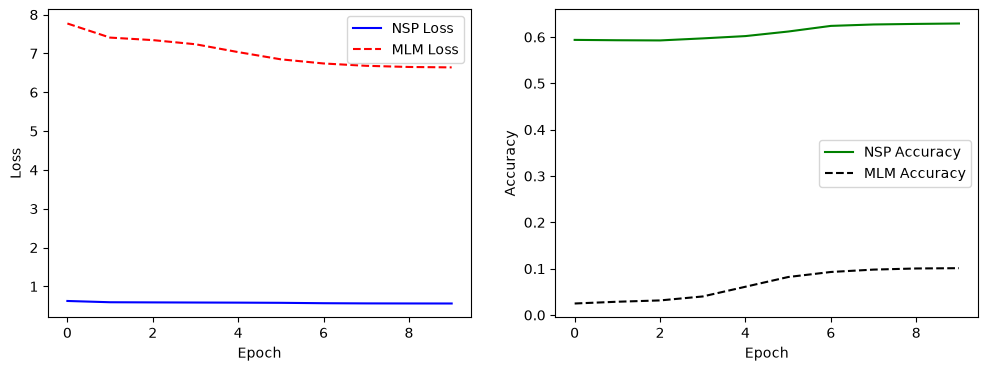

In [69]:
# [핵심] 두 과제의 loss와 accuracy 변화를 함께 시각화합니다.
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['nsp_loss'], 'b-', label='NSP Loss')
plt.plot(history['mlm_loss'], 'r--', label='MLM Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['nsp_acc'], 'g-', label='NSP Accuracy')
plt.plot(history['mlm_acc'], 'k--', label='MLM Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

## 8. 결과 분석 및 회고

### 학습 결과 분석

본 프로젝트에서는 vocabulary 8,007개와 약 101만 개 파라미터를 가진 mini BERT를 구현하고, 128,000개의 전처리 데이터를 사용해 MLM과 NSP를 동시에 10 epoch 학습했다.

| 지표 | Epoch 1 | Epoch 10 | 변화 |
|---|---:|---:|---:|
| NSP Loss | 0.6245 | 0.5595 | 감소 |
| MLM Loss | 7.7714 | 6.6410 | 감소 |
| NSP Accuracy | 59.38% | 62.92% | +3.54%p |
| MLM Accuracy | 2.49% | 10.11% | +7.62%p |

두 loss가 학습 내내 감소했고 두 accuracy도 상승했으므로, MLM과 NSP가 모두 정상적으로 학습되었다고 판단할 수 있다. 다만 8 epoch 이후 개선 폭이 작아져 수렴 구간에 진입한 모습을 보였다. MLM은 8,007개 후보 중 원래 토큰을 맞혀야 하므로 정확도가 NSP보다 낮게 나타났으며, 작은 모델과 제한된 학습 샘플 수 역시 성능을 제한하는 요인이다.

### 전체 학습 흐름

```mermaid
flowchart TD
    A["kowiki.txt 원문 코퍼스"] --> B["SentencePiece BPE tokenizer 학습\nvocab 8,007"]
    B --> C["Subword token 변환"]
    C --> D["MLM 데이터 생성\n단어 단위 15% 마스킹"]
    C --> E["NSP 데이터 생성\n문장 쌍 및 segment id 구성"]
    D --> F["전처리 예제 결합\ntokens, segments, MLM/NSP labels"]
    E --> F
    F --> G["JSONL 저장 및 np.memmap 로드\n128,000개 학습 샘플"]
    G --> H["mini BERT\nEmbedding + Transformer Encoder 2층"]
    H --> I["MLM Head"]
    H --> J["NSP Head"]
    I --> K["MLM Loss"]
    J --> L["NSP Loss"]
    K --> M["Loss 합산 및 역전파"]
    L --> M
    M --> N["10 epoch 학습\n체크포인트 및 그래프 저장"]
```

### 회고

이번 프로젝트를 통해 BERT 사전학습은 모델 구현뿐 아니라 tokenizer 학습, MLM·NSP 데이터 구성, 대용량 데이터 로드, 학습 지표 분석이 연결된 전체 파이프라인이라는 점을 이해했다. 특히 subword 조각이 아닌 단어 단위로 마스킹하는 방식이 모델이 지나치게 쉬운 단서에 의존하는 문제를 줄인다는 점이 인상적이었다.

로컬 환경에서는 데이터 경로와 UTF-8 인코딩을 명시해야 한글 위키 코퍼스를 안정적으로 처리할 수 있었다. 또한 `np.memmap`을 사용해 큰 전처리 데이터를 메모리 부담 없이 다룰 수 있었다. 이후에는 학습 데이터 수와 epoch를 늘리고, encoder layer 수나 hidden dimension을 조절해 성능 변화와 계산 비용의 trade-off를 비교해보고 싶다.
